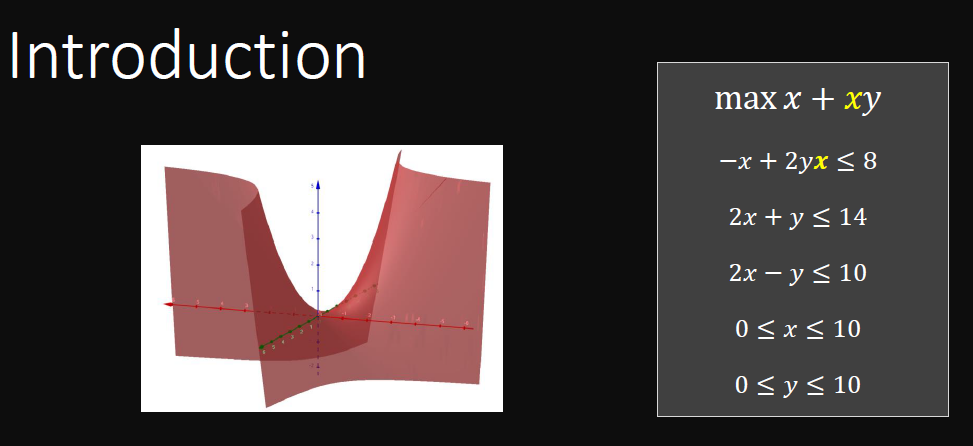

ex_NLP_pyomo

In [1]:
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.opt import SolverFactory

model = pyo.ConcreteModel()

model.x = pyo.Var(bounds=(0,10))
model.y = pyo.Var(bounds=(0,10))
x = model.x
y = model.y

model.C1 = pyo.Constraint(expr= -x+2*y*x<=8)
model.C2 = pyo.Constraint(expr= 2*x+y<=14)
model.C3 = pyo.Constraint(expr= 2*x-y<=10)

model.obj = pyo.Objective(expr= x+y*x, sense=maximize)

opt = SolverFactory('ipopt', executable=r"solvers\ipopt.exe")
opt.solve(model)

model.pprint()

x_value = pyo.value(x)
y_value = pyo.value(y)

print('\n---------------------------------------------------------------------')
print('x=',x_value)
print('y=',y_value)

2 Var Declarations
    x : Size=1, Index=None
        Key  : Lower : Value              : Upper : Fixed : Stale : Domain
        None :     0 : 5.6067151589768685 :    10 : False : False :  Reals
    y : Size=1, Index=None
        Key  : Lower : Value              : Upper : Fixed : Stale : Domain
        None :     0 : 1.2134302215032389 :    10 : False : False :  Reals

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : maximize : x + y*x

3 Constraint Declarations
    C1 : Size=1, Index=None, Active=True
        Key  : Lower : Body        : Upper : Active
        None :  -Inf : - x + 2*y*x :   8.0 :   True
    C2 : Size=1, Index=None, Active=True
        Key  : Lower : Body    : Upper : Active
        None :  -Inf : 2*x + y :  14.0 :   True
    C3 : Size=1, Index=None, Active=True
        Key  : Lower : Body    : Upper : Active
        None :  -Inf : 2*x - y :  10.0 :   True

6 Declarations: x y C1 

ex_NLP_scip

In [2]:
from pyscipopt import Model

model = Model('exemplo')

x = model.addVar('x')
y = model.addVar('y')
z = model.addVar('z')

model.setObjective(z, sense='maximize')

# NLP 要把 z 定義成約束條件，才能成功
model.addCons(z==x+y*x)
model.addCons(-x+2*y*x<=8)
model.addCons(2*x+y<=14)
model.addCons(2*x-y<=10)

model.optimize()

sol = model.getBestSol()

print('x=',sol[x])
print('y=',sol[y])

x= 5.606715160824649
y= 1.213430221663479


ex_NLP_exercise_cos

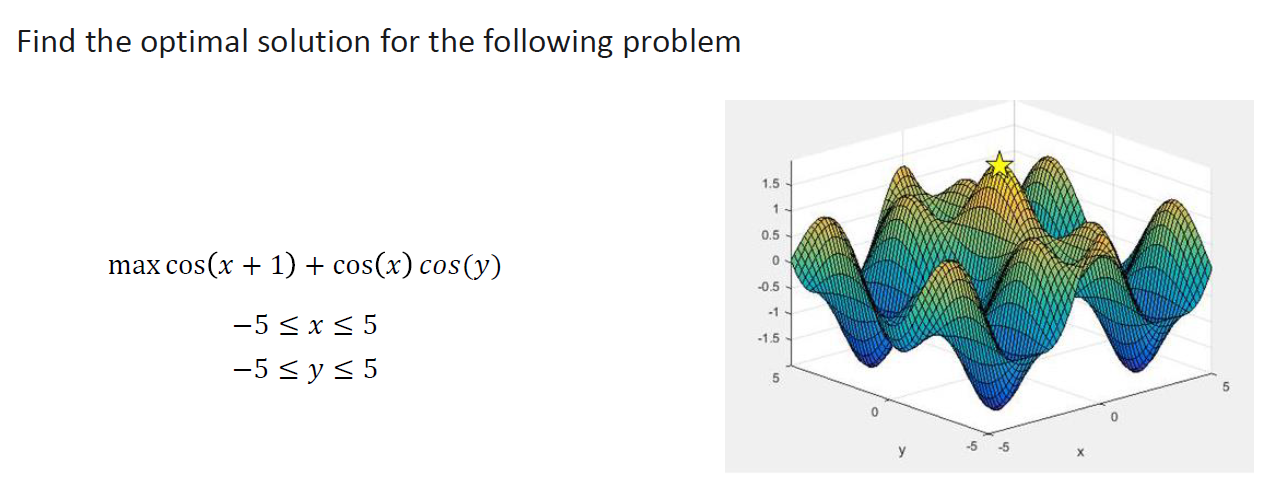

In [3]:
# 記得加 initialize & torlorance
# solver 只能找到 local solution 不能找到 global solution，所以 initialize 很重要

import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.opt import SolverFactory

model = pyo.ConcreteModel()

model.x = pyo.Var(initialize=0, bounds=(-5,5))
model.y = pyo.Var(initialize=0, bounds=(-5,5))
x = model.x
y = model.y

model.obj = pyo.Objective(expr = cos(x+1) + cos(x)*cos(y), sense=maximize)

opt = SolverFactory('ipopt')
opt.options['tol']=1e-6
opt.solve(model)

model.pprint()
print('x=',pyo.value(x))
print('y=',pyo.value(y))
print('objFun=',pyo.value(model.obj))

2 Var Declarations
    x : Size=1, Index=None
        Key  : Lower : Value               : Upper : Fixed : Stale : Domain
        None :    -5 : -0.4999999979072622 :     5 : False : False :  Reals
    y : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :    -5 :   0.0 :     5 : False : False :  Reals

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : maximize : cos(x + 1) + cos(x)*cos(y)

3 Declarations: x y obj
x= -0.4999999979072622
y= 0.0
objFun= 1.7551651237807455
